In [14]:
import sys

#!{sys.executable} -m pip install git+https://github.com/DepthAnything/Depth-Anything-V2.git
sys.path.append('../../Depth-Anything-V2/')
!{sys.executable} ls
!{sys.executable} -m pip install -r requirements.txt


/Users/andriimatsevytyi/anaconda3/bin/python: can't open file '/Users/andriimatsevytyi/Downloads/Automated-Glasses-Fitting/glasses preparation/notebooks/ls': [Errno 2] No such file or directory
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [15]:

from depth_anything_v2.dpt import DepthAnythingV2

# Load the model and infer depth from an image
import cv2
import torch



# instantiate the model
model = DepthAnythingV2(encoder="vitl", features=256, out_channels=[256, 512, 1024, 1024])

# load the weights
filepath = hf_hub_download(repo_id="depth-anything/Depth-Anything-V2-Large", filename="depth_anything_v2_vitl.pth", repo_type="model")
state_dict = torch.load(filepath, map_location="cpu")
model.load_state_dict(state_dict).eval()

raw_img = cv2.imread("../images/190605155141_01.png")
depth = model.infer_image(raw_img) # HxW raw depth map in numpy
    

xFormers not available
xFormers not available


NameError: name 'hf_hub_download' is not defined

/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/ipykernel_83921/1584719481.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkpo

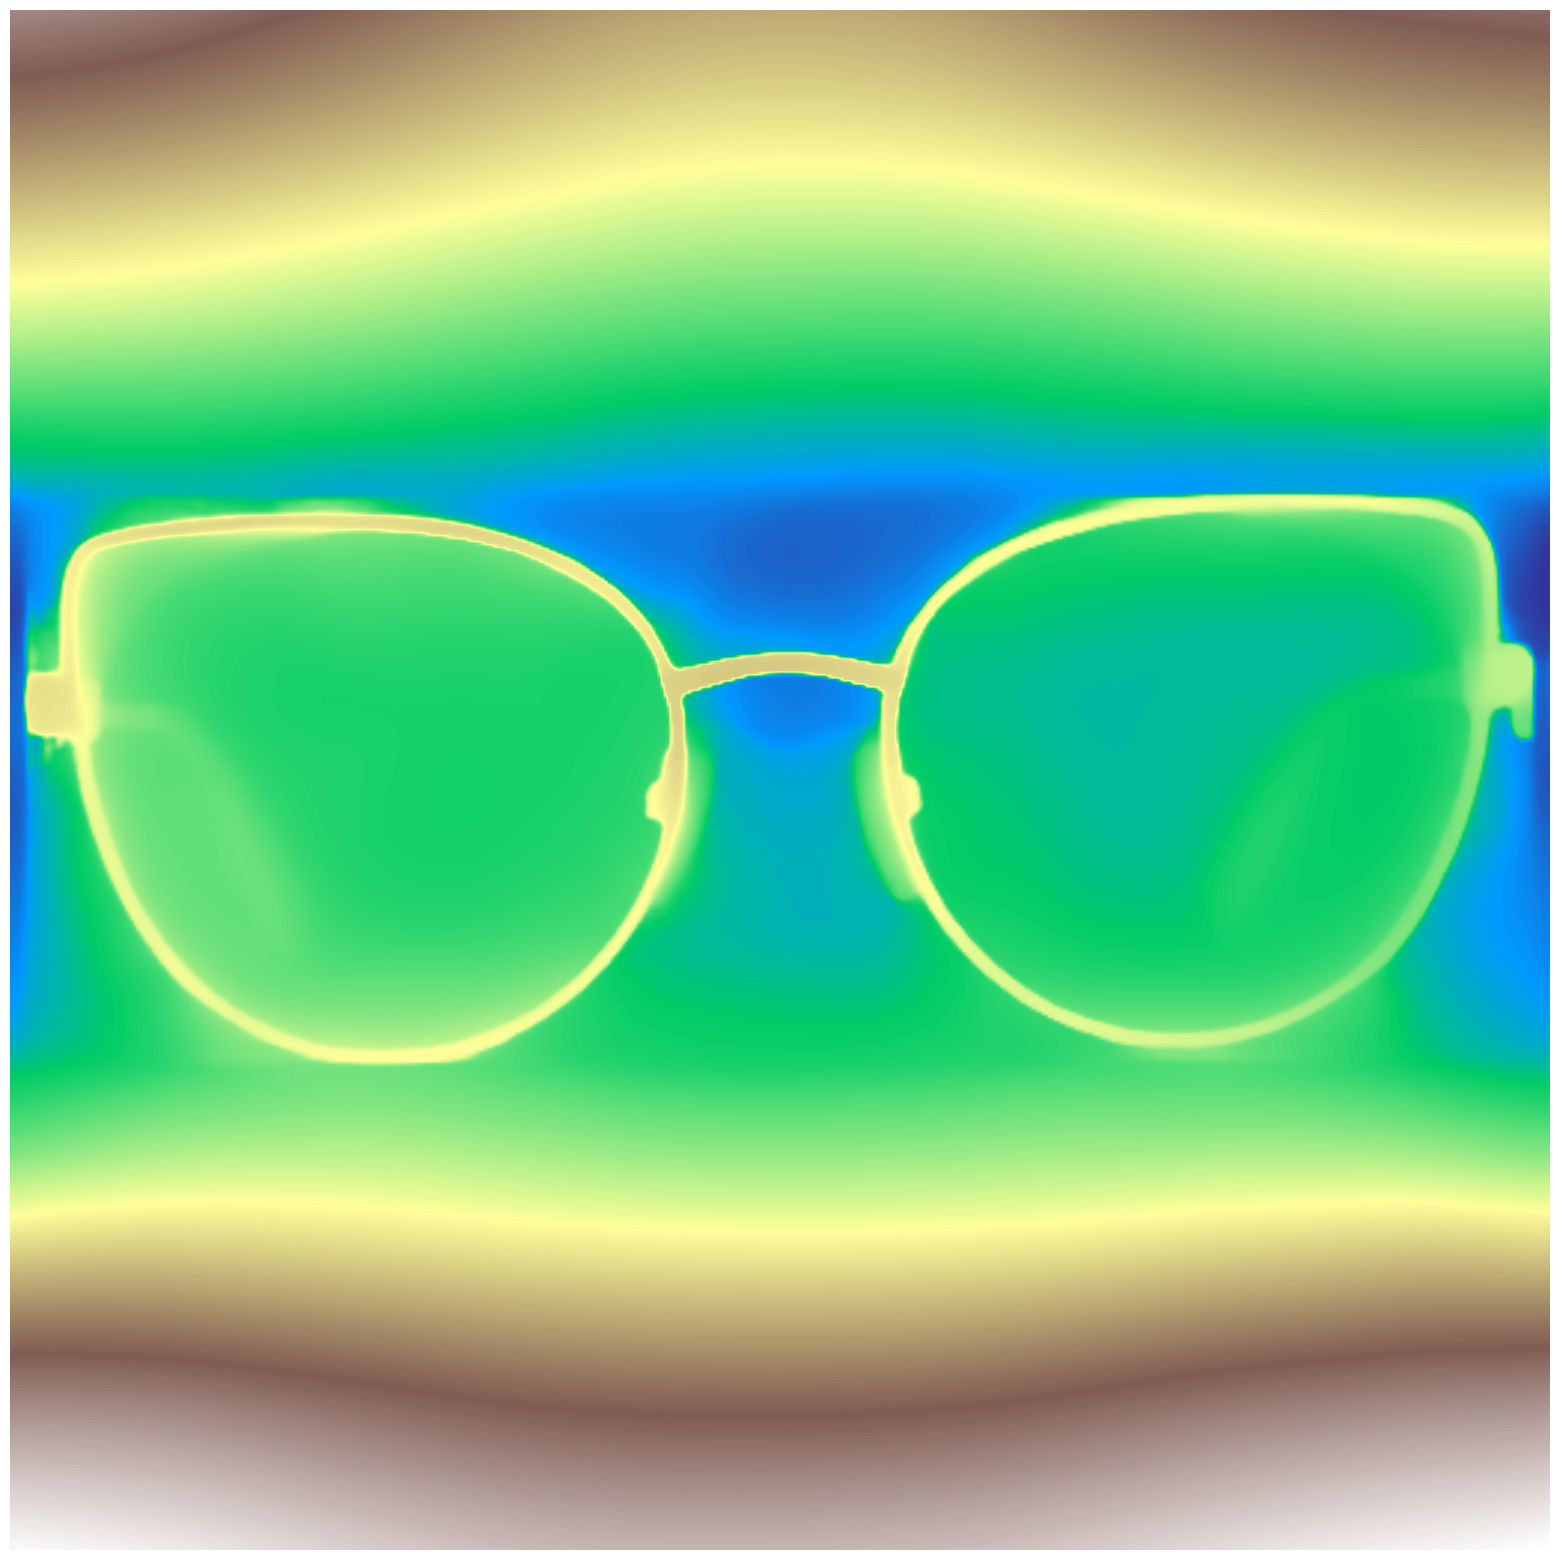

In [31]:
import cv2
import torch
import matplotlib.pyplot as plt

from depth_anything_v2.dpt import DepthAnythingV2

encoder='vitl'
model = DepthAnythingV2(encoder=encoder, features=256, out_channels=[256, 512, 1024, 1024]) #[48, 96, 192, 384] for small
model.load_state_dict(torch.load(f'../checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)
model.eval()

raw_img = cv2.imread('../images/190605155141_01.png')
depth = model.infer_image(raw_img) # HxW raw depth map
plt.figure(figsize=(20, 20))
plt.imshow(depth, cmap='terrain')
plt.axis('off')
plt.show()


/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/ipykernel_83921/3804635852.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../checkp

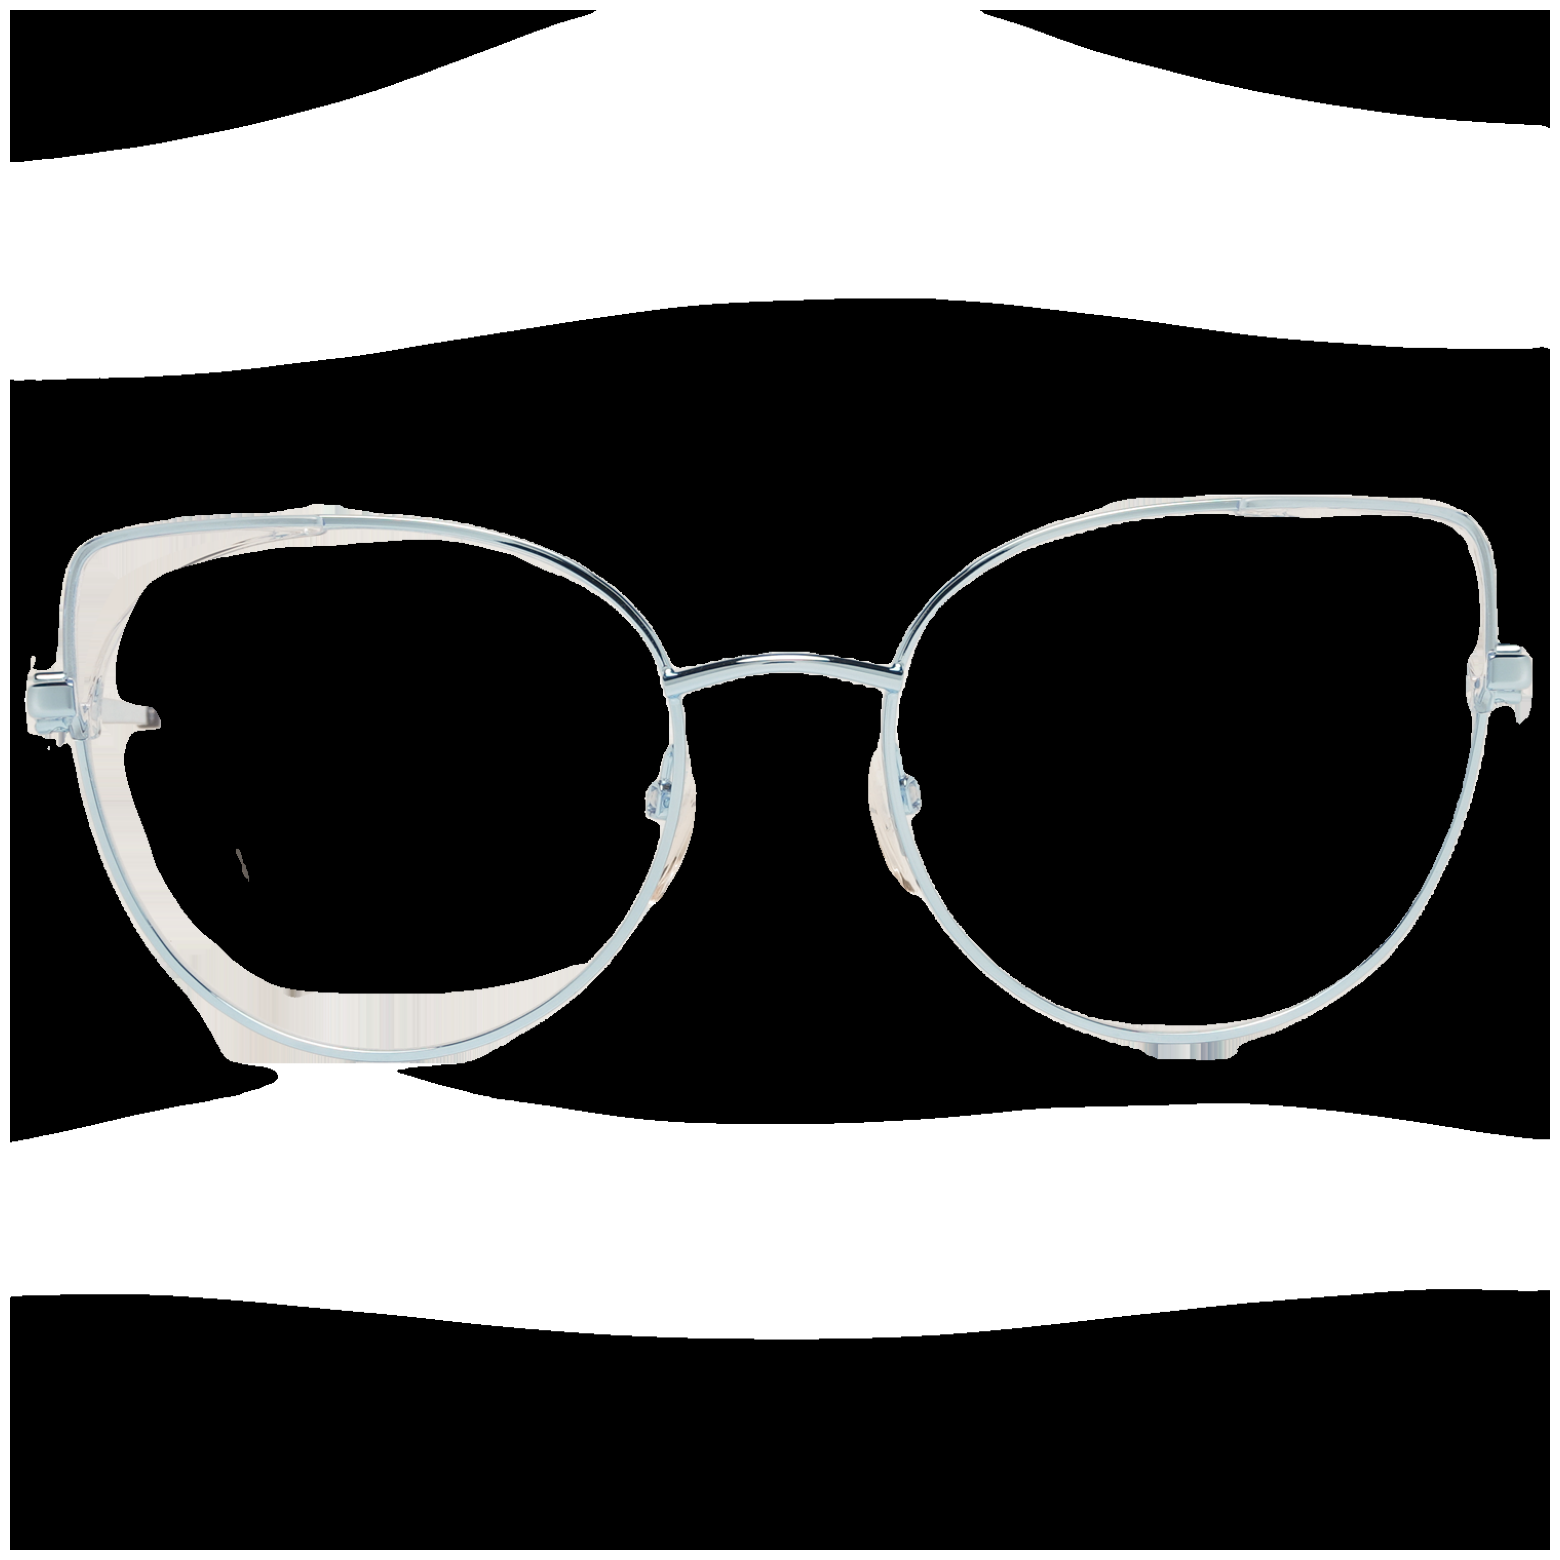

In [45]:
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

from depth_anything_v2.dpt import DepthAnythingV2

encoder='vitl'
model = DepthAnythingV2(encoder=encoder, features=256, out_channels=[256, 512, 1024, 1024]) #[48, 96, 192, 384] for small
model.load_state_dict(torch.load(f'../checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)
model.eval()

raw_img = cv2.imread('../images/190605155141_01.png')
depth = model.infer_image(raw_img) # HxW raw depth map

depth = depth.astype(np.uint8)

# Convert depth map to a binary mask (e.g., thresholding to keep only the closer objects)
_, binary_mask = cv2.threshold(depth, thresh=depth.mean()*1.15, maxval=1, type=cv2.THRESH_BINARY)

# Convert the binary mask to 3 channels to match the original image

# Apply the binary mask to the original image using bitwise AND
result = cv2.bitwise_and(raw_img, raw_img, mask=binary_mask.astype(np.uint8))

plt.figure(figsize=(20, 20))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()

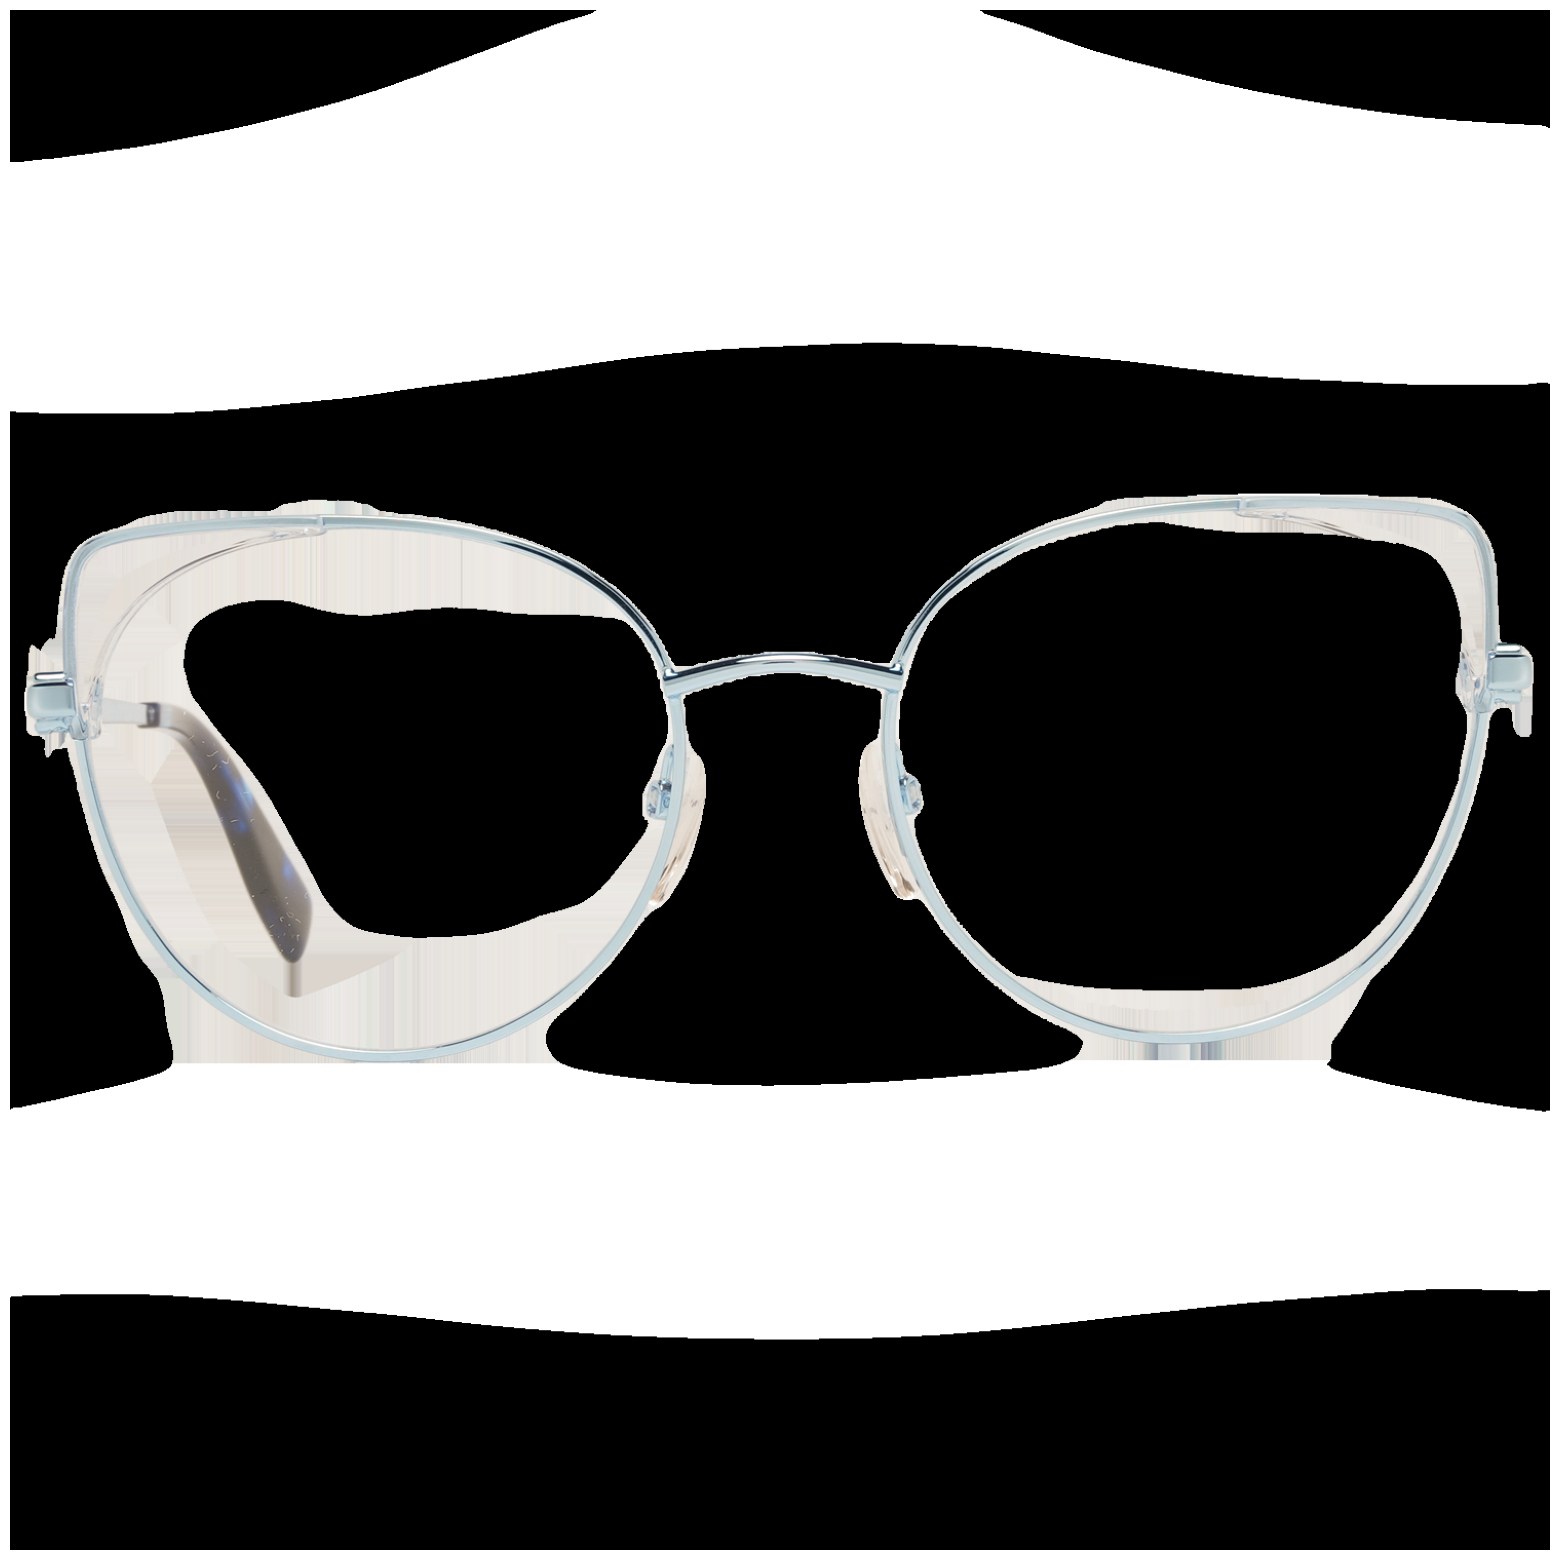

In [39]:

plt.figure(figsize=(20, 20))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()